In [ ]:
In diesem Notebook wird die Research Question 2 Analysiert

2. Gibt es Unterschiede im Trinkgeldverhalten je nach Tageszeit und Wochentag?
Analysiert werden:
- durchschnittlicher Trinkgeldbetrag
- durchschnittlicher Trinkgeldanteil
- Unterschiede nach Uhrzeit
- Unterschiede nach Wochentag
- Unterschiede zwischen Werktag und Wochenende

Für diese Analyse werden nur Fahrten mit elektronischer Zahlung betrachtet, da Bar-Trinkgelder im Datensatz nicht zuverlässig enthalten sind.


In [1]:
# SparkSession starten und benötigte Libraries importieren

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import os
import matplotlib.pyplot as plt

spark = SparkSession.builder \
    .appName("RQ2 Tip Behavior by Time") \
    .getOrCreate()

spark

26/05/25 14:28:12 WARN Utils: Your hostname, bdlc-021 resolves to a loopback address: 127.0.1.1; using 10.176.129.84 instead (on interface ens3)
26/05/25 14:28:12 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/25 14:28:13 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
# USE_SAMPLE = True  -> Analyse mit kleinem Parquet-Sample
# USE_SAMPLE = False -> Analyse mit vollständigem Clean-Datensatz aus HDFS

USE_SAMPLE = False

RQ_NAME = "rq2_tip_behavior_by_time"

if USE_SAMPLE:
    DATA_PATH = "file:///home/cluster/BDLC/data_sample/yellow_taxi_clean_sample_84000_parquet"
    RESULT_PATH = f"/home/cluster/BDLC/results/prototype/{RQ_NAME}"
else:
    DATA_PATH = "/taxi/clean"
    RESULT_PATH = f"/home/cluster/BDLC/results/final/{RQ_NAME}"

# Result-Ordner erstellen, falls er noch nicht existiert
os.makedirs(RESULT_PATH, exist_ok=True)

print("Using sample:", USE_SAMPLE)
print("Data path:", DATA_PATH)
print("Result path:", RESULT_PATH)

Using sample: False
Data path: /taxi/clean
Result path: /home/cluster/BDLC/results/final/rq2_tip_behavior_by_time


In [3]:
# Clean-Datensatz laden.
# Beim Sample wird das lokale Parquet-Sample gelesen.
# Beim vollständigen Datensatz wird /taxi/clean aus HDFS gelesen.

df = spark.read.parquet(DATA_PATH)

df.printSchema()
print("Number of records:", df.count())

26/05/25 14:28:26 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors
                                                                                

root
 |-- pickup_datetime: timestamp (nullable = true)
 |-- dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance_miles: double (nullable = true)
 |-- pickup_location_id: long (nullable = true)
 |-- dropoff_location_id: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- pickup_year: integer (nullable = true)
 |-- pickup_month: integer (nullable = true)
 |-- pickup_hour: integer (nullable = true)
 |-- pickup_weekday: integer (nullable = true)
 |-- trip_duration_minutes: double (nullable = true)
 |-- trip_distance_km: double (nullable = true)
 |-- avg_speed_kmh: double (nullable = true)
 |-- tip_percentage: double (nullable = true)
 |-- file_year: integer (nullable = true)
 |-- file_month: integer (nullable = true)



[Stage 1:======================================================>(164 + 1) / 165]

Number of records: 620366041


In [4]:
# Für die Trinkgeldanalyse werden nur elektronische Zahlungen verwendet.
# payment_type = 1 steht für Kreditkarte / elektronische Zahlung.
# Bar-Trinkgelder sind im Datensatz oft nicht zuverlässig erfasst.

df_tips = df.filter(F.col("payment_type") == 1)

print("Number of electronic payment records:", df_tips.count())

[Stage 4:======================================================>(162 + 3) / 165]

Number of electronic payment records: 420260764


In [5]:
# Zusätzlich zum absoluten Trinkgeldbetrag berechnen wir einen Trinkgeldanteil.
# total_amount enthält bereits das Trinkgeld.
# Deshalb berechnen wir zusätzlich den Betrag vor Trinkgeld:
# amount_before_tip = total_amount - tip_amount
#
# tip_rate_percent = tip_amount / amount_before_tip * 100
#
# Dadurch wird das Trinkgeld im Verhältnis zum Betrag vor Trinkgeld betrachtet.

df_tips = df_tips.withColumn(
    "amount_before_tip",
    F.col("total_amount") - F.col("tip_amount")
).withColumn(
    "tip_rate_percent",
    F.when(
        F.col("amount_before_tip") > 0,
        F.col("tip_amount") / F.col("amount_before_tip") * 100
    ).otherwise(None)
)

df_tips.select(
    "pickup_datetime",
    "pickup_hour",
    "pickup_weekday",
    "tip_amount",
    "total_amount",
    "amount_before_tip",
    "tip_rate_percent"
).show(10, truncate=False)

+-------------------+-----------+--------------+----------+------------+------------------+------------------+
|pickup_datetime    |pickup_hour|pickup_weekday|tip_amount|total_amount|amount_before_tip |tip_rate_percent  |
+-------------------+-----------+--------------+----------+------------+------------------+------------------+
|2017-11-01 00:18:22|0          |4             |2.0       |20.8        |18.8              |10.638297872340425|
|2017-11-01 00:01:58|0          |4             |3.05      |18.35       |15.3              |19.934640522875817|
|2017-11-01 00:18:53|0          |4             |1.32      |10.12       |8.799999999999999 |15.000000000000002|
|2017-11-01 00:28:56|0          |4             |2.0       |12.3        |10.3              |19.41747572815534 |
|2017-11-01 00:40:35|0          |4             |2.45      |10.75       |8.3               |29.518072289156628|
|2017-11-01 00:19:29|0          |4             |1.85      |8.15        |6.300000000000001 |29.36507936507936 |
|

In [6]:
# Erste Übersicht über Trinkgeldbetrag und Trinkgeldanteil.
# Damit prüfen wir, ob die Werte plausibel aussehen.

df_tips.select(
    "tip_amount",
    "total_amount",
    "amount_before_tip",
    "tip_rate_percent"
).describe().show()

26/05/25 14:29:01 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
[Stage 8:======================================================>(163 + 2) / 165]

+-------+-----------------+------------------+------------------+------------------+
|summary|       tip_amount|      total_amount| amount_before_tip|  tip_rate_percent|
+-------+-----------------+------------------+------------------+------------------+
|  count|        420260764|         420260764|         420260764|         420260755|
|   mean|2.775296773126048|18.083987019261265|15.308690246171691|18.727880097418517|
| stddev|2.675555539343546| 14.36719157160129|12.219762052134168| 73.75414851306424|
|    min|              0.0|              0.01|               0.0|               0.0|
|    max|           969.69|            999.18|            999.18|199999.99999996874|
+-------+-----------------+------------------+------------------+------------------+



In [7]:
# Obwohl die Daten bereits bereinigt sind, entfernen wir für diese Analyse noch Fälle,
# bei denen der berechnete Trinkgeldanteil NULL oder extrem hoch ist.
# Sehr hohe Trinkgeldanteile können einzelne Sonderfälle oder Datenfehler sein.
#
# Grenzwert: max. 100% Trinkgeldanteil.
# Das ist grosszügig, entfernt aber extreme Ausreisser.

df_tips_clean = df_tips \
    .filter(F.col("tip_rate_percent").isNotNull()) \
    .filter(~F.isnan(F.col("tip_rate_percent"))) \
    .filter(F.col("tip_rate_percent") >= 0) \
    .filter(F.col("tip_rate_percent") <= 100)

print("Records after tip-rate filtering:", df_tips_clean.count())

[Stage 11:====================================================> (159 + 6) / 165]

Records after tip-rate filtering: 420002871


In [8]:
# Spark dayofweek:
# 1 = Sunday
# 2 = Monday
# 3 = Tuesday
# 4 = Wednesday
# 5 = Thursday
# 6 = Friday
# 7 = Saturday
#
# Für die Darstellung soll die Woche mit Monday beginnen.
# Deshalb erstellen wir zusätzlich weekday_order:
# Monday = 1, ..., Sunday = 7

df_tips_clean = df_tips_clean.withColumn(
    "weekday_name",
    F.when(F.col("pickup_weekday") == 1, "Sunday")
     .when(F.col("pickup_weekday") == 2, "Monday")
     .when(F.col("pickup_weekday") == 3, "Tuesday")
     .when(F.col("pickup_weekday") == 4, "Wednesday")
     .when(F.col("pickup_weekday") == 5, "Thursday")
     .when(F.col("pickup_weekday") == 6, "Friday")
     .when(F.col("pickup_weekday") == 7, "Saturday")
).withColumn(
    "weekday_order",
    F.when(F.col("pickup_weekday") == 2, 1)  # Monday
     .when(F.col("pickup_weekday") == 3, 2)  # Tuesday
     .when(F.col("pickup_weekday") == 4, 3)  # Wednesday
     .when(F.col("pickup_weekday") == 5, 4)  # Thursday
     .when(F.col("pickup_weekday") == 6, 5)  # Friday
     .when(F.col("pickup_weekday") == 7, 6)  # Saturday
     .when(F.col("pickup_weekday") == 1, 7)  # Sunday
)

In [ ]:
Analyse 1: Trinkgeld nach Uhrzeit

In [9]:
# Trinkgeldverhalten pro Stunde berechnen.
# Wir verwenden:
# - Anzahl Fahrten
# - durchschnittlicher Trinkgeldbetrag
# - durchschnittlicher Trinkgeldanteil
# - Median des Trinkgeldanteils als robustere Kennzahl

tips_by_hour = df_tips_clean.groupBy("pickup_hour") \
    .agg(
        F.count("*").alias("number_of_trips"),
        F.round(F.avg("tip_amount"), 2).alias("avg_tip_amount"),
        F.round(F.avg("tip_rate_percent"), 2).alias("avg_tip_rate_percent"),
        F.round(F.expr("percentile_approx(tip_rate_percent, 0.5)"), 2).alias("median_tip_rate_percent")
    ) \
    .orderBy("pickup_hour")

tips_by_hour.show(24)

[Stage 16:====================================================>   (16 + 1) / 17]

+-----------+---------------+--------------+--------------------+-----------------------+
|pickup_hour|number_of_trips|avg_tip_amount|avg_tip_rate_percent|median_tip_rate_percent|
+-----------+---------------+--------------+--------------------+-----------------------+
|          0|       14294575|          2.78|               18.18|                  19.97|
|          1|       10149147|           2.6|               18.03|                  19.96|
|          2|        7154701|          2.47|               17.81|                  19.95|
|          3|        5009561|          2.51|               17.53|                  19.95|
|          4|        3353562|          3.11|                17.5|                  19.95|
|          5|        3701527|          3.57|               17.82|                  19.95|
|          6|        9053151|          2.77|                18.0|                  19.93|
|          7|       16297192|          2.52|               18.23|                  19.95|
|         

In [10]:
# Aggregierte Tabelle als CSV speichern.

tips_by_hour_pd = tips_by_hour.toPandas()

tips_by_hour_pd.to_csv(
    f"{RESULT_PATH}/tips_by_hour.csv",
    index=False
)

tips_by_hour_pd

,pickup_hour,number_of_trips,avg_tip_amount,avg_tip_rate_percent,median_tip_rate_percent
0,0,14294575,2.78,18.18,19.97
1,1,10149147,2.60,18.03,19.96
2,2,7154701,2.47,17.81,19.95
3,3,5009561,2.51,17.53,19.95
4,4,3353562,3.11,17.50,19.95
5,5,3701527,3.57,17.82,19.95
6,6,9053151,2.77,18.00,19.93
7,7,16297192,2.52,18.23,19.95
8,8,20568160,2.53,18.36,19.97
9,9,20176222,2.59,18.56,20.00


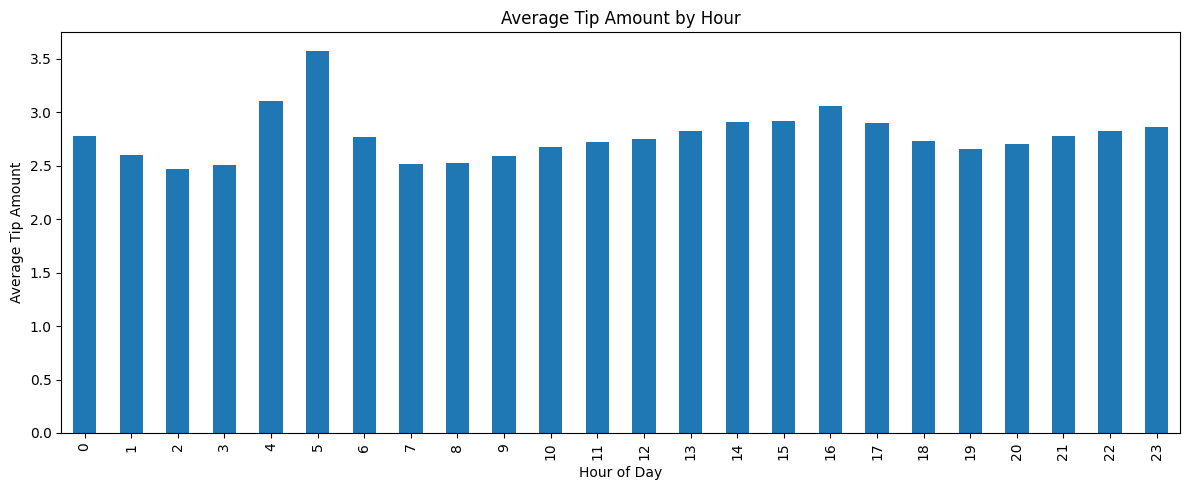

In [11]:
# Balkendiagramm: durchschnittlicher Trinkgeldbetrag pro Stunde.

ax = tips_by_hour_pd.plot(
    x="pickup_hour",
    y="avg_tip_amount",
    kind="bar",
    figsize=(12, 5),
    legend=False,
    title="Average Tip Amount by Hour"
)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Average Tip Amount")

plt.tight_layout()
plt.savefig(f"{RESULT_PATH}/avg_tip_amount_by_hour.png", dpi=150)
plt.show()

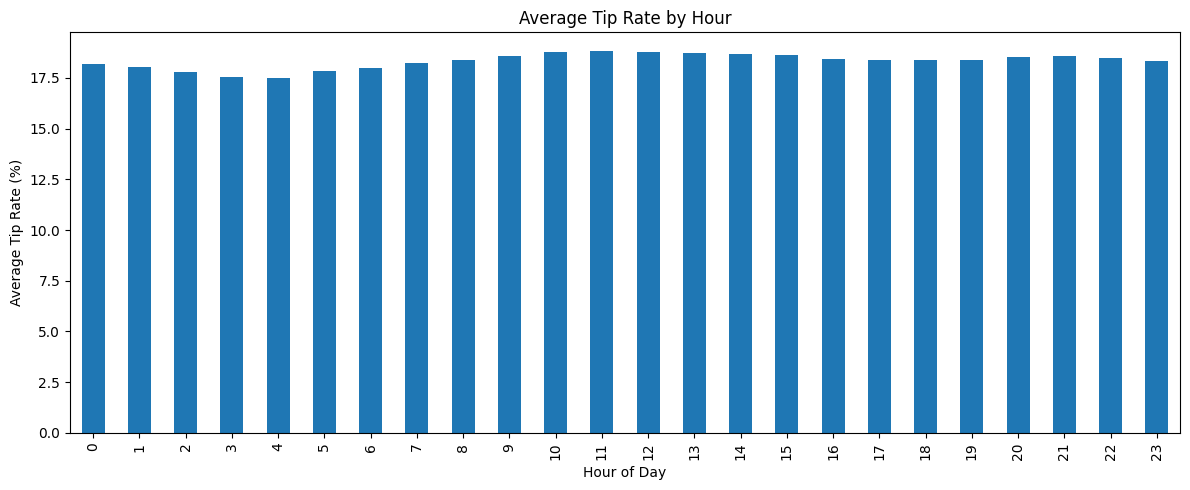

In [12]:
# Balkendiagramm: durchschnittlicher Trinkgeldanteil pro Stunde.
# Diese Kennzahl ist besser vergleichbar als der reine Trinkgeldbetrag.

ax = tips_by_hour_pd.plot(
    x="pickup_hour",
    y="avg_tip_rate_percent",
    kind="bar",
    figsize=(12, 5),
    legend=False,
    title="Average Tip Rate by Hour"
)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Average Tip Rate (%)")

plt.tight_layout()
plt.savefig(f"{RESULT_PATH}/avg_tip_rate_by_hour.png", dpi=150)
plt.show()

In [13]:
# Stunde mit dem höchsten durchschnittlichen Trinkgeldanteil bestimmen.

tips_by_hour.orderBy(F.desc("avg_tip_rate_percent")).limit(5).show()

[Stage 27:====================================================>   (16 + 1) / 17]

+-----------+---------------+--------------+--------------------+-----------------------+
|pickup_hour|number_of_trips|avg_tip_amount|avg_tip_rate_percent|median_tip_rate_percent|
+-----------+---------------+--------------+--------------------+-----------------------+
|         11|       19397814|          2.72|                18.8|                   20.0|
|         10|       18930514|          2.68|               18.77|                   20.0|
|         12|       20481649|          2.75|               18.75|                   20.0|
|         13|       20457654|          2.83|               18.73|                   20.0|
|         14|       21398938|          2.91|               18.68|                   20.0|
+-----------+---------------+--------------+--------------------+-----------------------+



In [ ]:
Analyse 2: Trinkgeld nach Wochentag

In [14]:
# Trinkgeldverhalten pro Wochentag berechnen.
# Sortiert wird mit weekday_order, damit Monday zuerst kommt.

tips_by_weekday = df_tips_clean.groupBy(
    "weekday_order",
    "weekday_name"
).agg(
    F.count("*").alias("number_of_trips"),
    F.round(F.avg("tip_amount"), 2).alias("avg_tip_amount"),
    F.round(F.avg("tip_rate_percent"), 2).alias("avg_tip_rate_percent"),
    F.round(F.expr("percentile_approx(tip_rate_percent, 0.5)"), 2).alias("median_tip_rate_percent")
).orderBy("weekday_order")

tips_by_weekday.show()

[Stage 30:=================================================>        (6 + 1) / 7]

+-------------+------------+---------------+--------------+--------------------+-----------------------+
|weekday_order|weekday_name|number_of_trips|avg_tip_amount|avg_tip_rate_percent|median_tip_rate_percent|
+-------------+------------+---------------+--------------+--------------------+-----------------------+
|            1|      Monday|       53983435|          2.82|               18.56|                  19.99|
|            2|     Tuesday|       60467078|          2.78|                18.6|                   20.0|
|            3|   Wednesday|       63415774|          2.81|               18.58|                   20.0|
|            4|    Thursday|       65271103|          2.85|               18.53|                   20.0|
|            5|      Friday|       64560026|          2.79|               18.35|                  19.98|
|            6|    Saturday|       59960544|          2.56|               18.26|                  19.98|
|            7|      Sunday|       52344911|          2

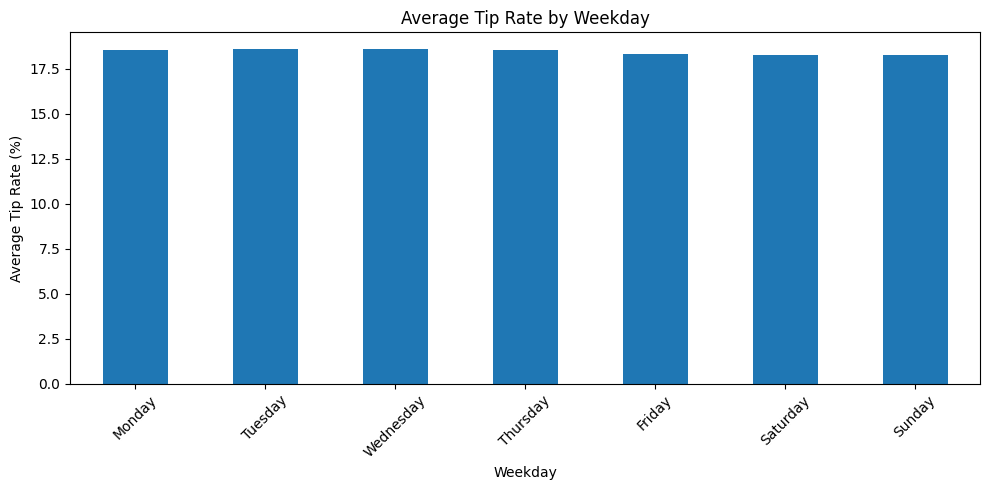

In [15]:
# Tabelle speichern und durchschnittlichen Trinkgeldanteil pro Wochentag visualisieren.
# Die Reihenfolge ist bereits durch weekday_order korrekt vorbereitet.

tips_by_weekday_pd = tips_by_weekday.toPandas()

tips_by_weekday_pd.to_csv(
    f"{RESULT_PATH}/tips_by_weekday.csv",
    index=False
)

ax = tips_by_weekday_pd.plot(
    x="weekday_name",
    y="avg_tip_rate_percent",
    kind="bar",
    figsize=(10, 5),
    legend=False,
    title="Average Tip Rate by Weekday"
)

ax.set_xlabel("Weekday")
ax.set_ylabel("Average Tip Rate (%)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{RESULT_PATH}/avg_tip_rate_by_weekday.png", dpi=150)
plt.show()

In [ ]:
Analyse 3: Werktag vs Wochenende

In [16]:
# Neue Kategorie erstellen:
# Weekend = Samstag oder Sonntag
# Weekday = Montag bis Freitag

df_tips_day_type = df_tips_clean.withColumn(
    "day_type",
    F.when(F.col("pickup_weekday").isin(1, 7), "Weekend")
     .otherwise("Weekday")
)

In [17]:
# Trinkgeldverhalten zwischen Werktag und Wochenende vergleichen.

tips_by_day_type = df_tips_day_type.groupBy("day_type") \
    .agg(
        F.count("*").alias("number_of_trips"),
        F.round(F.avg("tip_amount"), 2).alias("avg_tip_amount"),
        F.round(F.avg("tip_rate_percent"), 2).alias("avg_tip_rate_percent"),
        F.round(F.expr("percentile_approx(tip_rate_percent, 0.5)"), 2).alias("median_tip_rate_percent")
    ) \
    .orderBy("day_type")

tips_by_day_type.show()

[Stage 41:=============================>                            (1 + 1) / 2]

+--------+---------------+--------------+--------------------+-----------------------+
|day_type|number_of_trips|avg_tip_amount|avg_tip_rate_percent|median_tip_rate_percent|
+--------+---------------+--------------+--------------------+-----------------------+
| Weekday|      307697416|          2.81|               18.52|                   20.0|
| Weekend|      112305455|          2.64|               18.27|                  19.98|
+--------+---------------+--------------+--------------------+-----------------------+



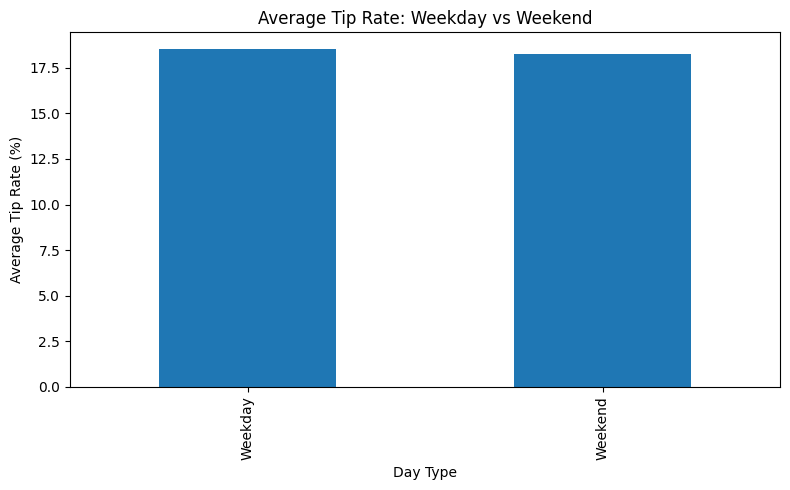

In [18]:
# Tabelle speichern und Vergleich visualisieren.

tips_by_day_type_pd = tips_by_day_type.toPandas()

tips_by_day_type_pd.to_csv(
    f"{RESULT_PATH}/tips_by_day_type.csv",
    index=False
)

ax = tips_by_day_type_pd.plot(
    x="day_type",
    y="avg_tip_rate_percent",
    kind="bar",
    figsize=(8, 5),
    legend=False,
    title="Average Tip Rate: Weekday vs Weekend"
)

ax.set_xlabel("Day Type")
ax.set_ylabel("Average Tip Rate (%)")

plt.tight_layout()
plt.savefig(f"{RESULT_PATH}/avg_tip_rate_weekday_vs_weekend.png", dpi=150)
plt.show()

In [ ]:
Analyse 4: Heatmap Wochentag × Uhrzeit

In [19]:
# Trinkgeldanteil nach Wochentag und Stunde berechnen.
# Diese Heatmap zeigt, ob es bestimmte Zeitfenster mit höherem Trinkgeldanteil gibt.
# Sortiert wird mit weekday_order, damit Monday zuerst kommt.

tips_weekday_hour = df_tips_clean.groupBy(
    "weekday_order",
    "weekday_name",
    "pickup_hour"
).agg(
    F.count("*").alias("number_of_trips"),
    F.round(F.avg("tip_rate_percent"), 2).alias("avg_tip_rate_percent")
).orderBy(
    "weekday_order",
    "pickup_hour"
)

tips_weekday_hour.show(200)

[Stage 50:===================================================>  (158 + 7) / 165]

+-------------+------------+-----------+---------------+--------------------+
|weekday_order|weekday_name|pickup_hour|number_of_trips|avg_tip_rate_percent|
+-------------+------------+-----------+---------------+--------------------+
|            1|      Monday|          0|        1018362|               18.06|
|            1|      Monday|          1|         577008|               17.99|
|            1|      Monday|          2|         356512|               17.96|
|            1|      Monday|          3|         238559|                17.7|
|            1|      Monday|          4|         276748|               17.72|
|            1|      Monday|          5|         561340|               17.81|
|            1|      Monday|          6|        1486160|               17.88|
|            1|      Monday|          7|        2598833|               18.13|
|            1|      Monday|          8|        3197228|               18.26|
|            1|      Monday|          9|        2931910|        

In [20]:
# Ergebnis als CSV speichern.

tips_weekday_hour_pd = tips_weekday_hour.toPandas()

tips_weekday_hour_pd.to_csv(
    f"{RESULT_PATH}/tips_weekday_hour.csv",
    index=False
)

tips_weekday_hour_pd.head()

,weekday_order,weekday_name,pickup_hour,number_of_trips,avg_tip_rate_percent
0,1,Monday,0,1018362,18.06
1,1,Monday,1,577008,17.99
2,1,Monday,2,356512,17.96
3,1,Monday,3,238559,17.70
4,1,Monday,4,276748,17.72


In [21]:
# Pivot-Tabelle erstellen:
# Zeilen = Wochentage
# Spalten = Stunden
# Werte = durchschnittlicher Trinkgeldanteil
#
# Die Reihenfolge wird manuell auf Monday bis Sunday gesetzt.

heatmap_tip_weekday_hour = tips_weekday_hour_pd.pivot(
    index="weekday_name",
    columns="pickup_hour",
    values="avg_tip_rate_percent"
)

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

heatmap_tip_weekday_hour = heatmap_tip_weekday_hour.reindex(weekday_order)

heatmap_tip_weekday_hour

pickup_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
weekday_name,,,,,,,,,,,,,,,,,,,,,
Monday,18.06,17.99,17.96,17.70,17.72,17.81,17.88,18.13,18.26,18.55,...,18.82,18.74,18.46,18.42,18.42,18.47,18.72,18.84,18.79,18.65
Tuesday,18.57,18.56,18.52,18.19,17.94,17.92,17.99,18.24,18.34,18.55,...,18.84,18.76,18.47,18.41,18.41,18.43,18.71,18.81,18.75,18.64
Wednesday,18.60,18.56,18.44,18.14,18.00,18.00,18.05,18.28,18.38,18.58,...,18.81,18.74,18.45,18.37,18.36,18.38,18.67,18.76,18.69,18.59
Thursday,18.55,18.51,18.36,18.08,18.03,18.05,18.09,18.28,18.37,18.56,...,18.81,18.71,18.44,18.34,18.32,18.32,18.55,18.63,18.53,18.40
Friday,18.33,18.25,18.07,17.78,17.82,17.96,18.02,18.15,18.28,18.45,...,18.60,18.52,18.22,18.18,18.21,18.21,18.35,18.40,18.32,18.09
Saturday,17.92,17.78,17.57,17.32,17.20,17.43,17.98,18.33,18.52,18.65,...,18.42,18.43,18.52,18.54,18.50,18.40,18.10,18.16,18.14,17.95
Sunday,17.85,17.75,17.56,17.33,17.15,17.29,17.76,18.19,18.64,18.70,...,18.44,18.40,18.45,18.48,18.53,18.52,18.36,18.38,18.26,18.13


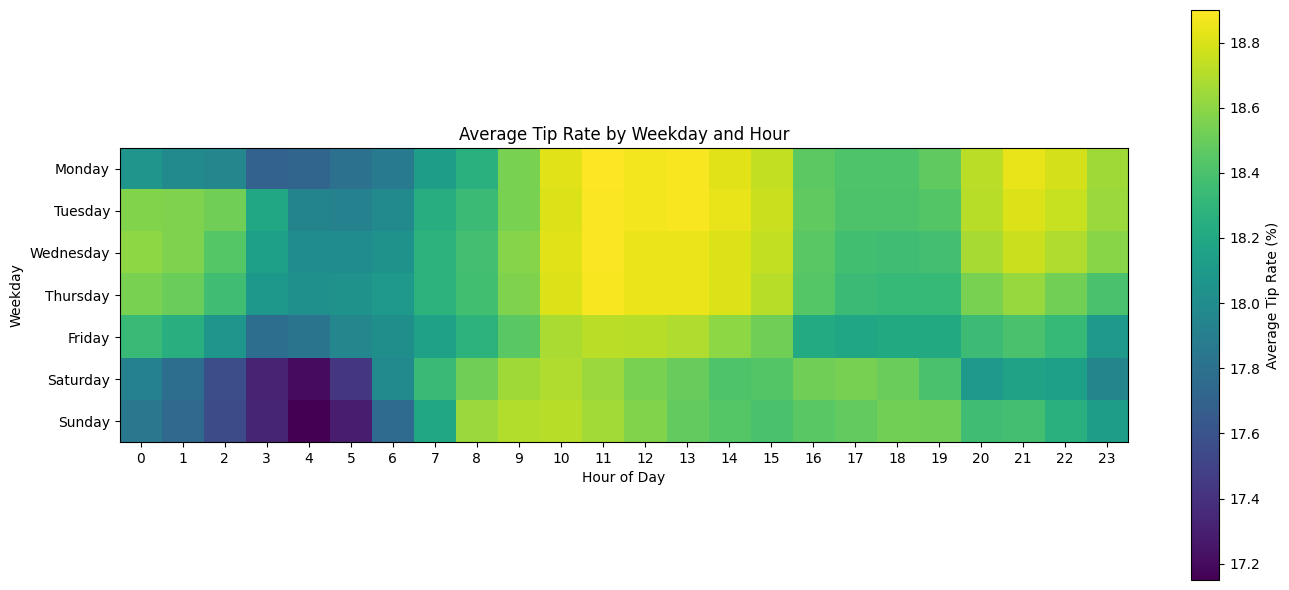

In [22]:
# Heatmap für Trinkgeldanteil nach Wochentag und Uhrzeit.

fig, ax = plt.subplots(figsize=(14, 6))

image = ax.imshow(heatmap_tip_weekday_hour)

ax.set_xticks(range(len(heatmap_tip_weekday_hour.columns)))
ax.set_xticklabels(heatmap_tip_weekday_hour.columns)

ax.set_yticks(range(len(heatmap_tip_weekday_hour.index)))
ax.set_yticklabels(heatmap_tip_weekday_hour.index)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Weekday")
ax.set_title("Average Tip Rate by Weekday and Hour")

plt.colorbar(image, ax=ax, label="Average Tip Rate (%)")

plt.tight_layout()
plt.savefig(f"{RESULT_PATH}/heatmap_tip_rate_weekday_hour.png", dpi=150)
plt.show()

In [ ]:
Analyse 5: Heatmap Werktag/Wochenende × Uhrzeit

In [23]:
# Trinkgeldanteil nach Weekday/Weekend und Stunde berechnen.

tips_day_type_hour = df_tips_day_type.groupBy(
    "day_type",
    "pickup_hour"
).agg(
    F.count("*").alias("number_of_trips"),
    F.round(F.avg("tip_rate_percent"), 2).alias("avg_tip_rate_percent")
).orderBy(
    "day_type",
    "pickup_hour"
)

tips_day_type_hour.show(100)

[Stage 61:===================================================>  (158 + 7) / 165]

+--------+-----------+---------------+--------------------+
|day_type|pickup_hour|number_of_trips|avg_tip_rate_percent|
+--------+-----------+---------------+--------------------+
| Weekday|          0|        7747778|               18.43|
| Weekday|          1|        4417330|               18.37|
| Weekday|          2|        2628128|               18.24|
| Weekday|          3|        1642212|               17.95|
| Weekday|          4|        1521713|                17.9|
| Weekday|          5|        2880018|               17.95|
| Weekday|          6|        7960713|               18.01|
| Weekday|          7|       14631997|               18.22|
| Weekday|          8|       17968228|               18.33|
| Weekday|          9|       16397576|               18.54|
| Weekday|         10|       14133421|               18.79|
| Weekday|         11|       13912009|               18.86|
| Weekday|         12|       14479574|               18.83|
| Weekday|         13|       14419800|  

In [24]:
# Tabelle speichern und Pivot-Tabelle für Heatmap erstellen.

tips_day_type_hour_pd = tips_day_type_hour.toPandas()

tips_day_type_hour_pd.to_csv(
    f"{RESULT_PATH}/tips_day_type_hour.csv",
    index=False
)

heatmap_tip_day_type_hour = tips_day_type_hour_pd.pivot(
    index="day_type",
    columns="pickup_hour",
    values="avg_tip_rate_percent"
)

heatmap_tip_day_type_hour = heatmap_tip_day_type_hour.reindex(["Weekday", "Weekend"])

heatmap_tip_day_type_hour

pickup_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day_type,,,,,,,,,,,,,,,,,,,,,
Weekday,18.43,18.37,18.24,17.95,17.90,17.95,18.01,18.22,18.33,18.54,...,18.78,18.69,18.41,18.34,18.34,18.36,18.60,18.69,18.60,18.43
Weekend,17.89,17.76,17.56,17.32,17.17,17.36,17.88,18.27,18.57,18.68,...,18.43,18.42,18.49,18.51,18.51,18.45,18.22,18.26,18.19,18.01


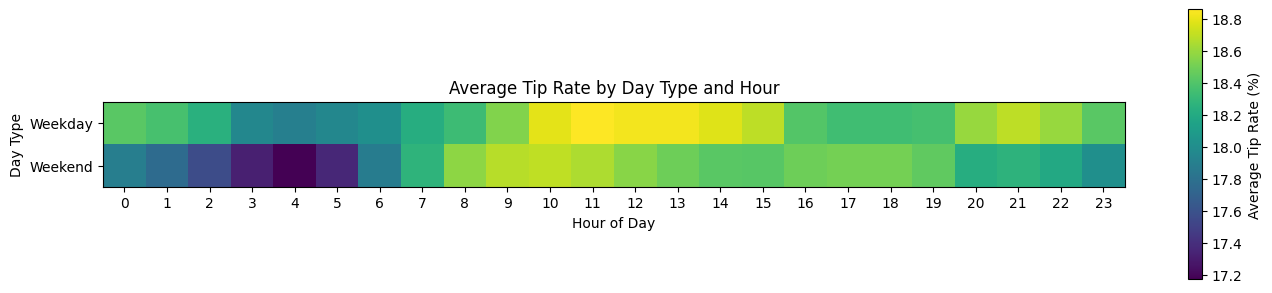

In [25]:
# Heatmap für Trinkgeldanteil nach Weekday/Weekend und Uhrzeit.

fig, ax = plt.subplots(figsize=(14, 3))

image = ax.imshow(heatmap_tip_day_type_hour)

ax.set_xticks(range(len(heatmap_tip_day_type_hour.columns)))
ax.set_xticklabels(heatmap_tip_day_type_hour.columns)

ax.set_yticks(range(len(heatmap_tip_day_type_hour.index)))
ax.set_yticklabels(heatmap_tip_day_type_hour.index)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Day Type")
ax.set_title("Average Tip Rate by Day Type and Hour")

plt.colorbar(image, ax=ax, label="Average Tip Rate (%)")

plt.tight_layout()
plt.savefig(f"{RESULT_PATH}/heatmap_tip_rate_day_type_hour.png", dpi=150)
plt.show()

In [ ]:
Analyse 5: Vor-Corona vs. Corona-Zeitraum

In [26]:
# Optionaler Vergleich:
# 2015-2019 = vor Corona
# 2020-2021 = Corona-Zeitraum

df_tips_period = df_tips_clean.withColumn(
    "period",
    F.when(F.col("file_year").between(2015, 2019), "2015-2019")
     .when(F.col("file_year").between(2020, 2021), "2020-2021")
)

In [27]:
# Trinkgeldanteil pro Stunde und Periode berechnen.

tips_by_hour_period = df_tips_period.groupBy(
    "period",
    "pickup_hour"
).agg(
    F.count("*").alias("number_of_trips"),
    F.round(F.avg("tip_rate_percent"), 2).alias("avg_tip_rate_percent")
).orderBy(
    "period",
    "pickup_hour"
)

tips_by_hour_period.show(100)

[Stage 72:===================================================>  (158 + 7) / 165]

+---------+-----------+---------------+--------------------+
|   period|pickup_hour|number_of_trips|avg_tip_rate_percent|
+---------+-----------+---------------+--------------------+
|2015-2019|          0|       13436119|               18.19|
|2015-2019|          1|        9589971|               18.03|
|2015-2019|          2|        6792612|               17.82|
|2015-2019|          3|        4776361|               17.53|
|2015-2019|          4|        3205814|                17.5|
|2015-2019|          5|        3497459|               17.83|
|2015-2019|          6|        8432649|               18.01|
|2015-2019|          7|       15057057|               18.24|
|2015-2019|          8|       18837896|               18.36|
|2015-2019|          9|       18368293|               18.56|
|2015-2019|         10|       17049323|               18.76|
|2015-2019|         11|       17380289|               18.79|
|2015-2019|         12|       18273668|               18.74|
|2015-2019|         13| 

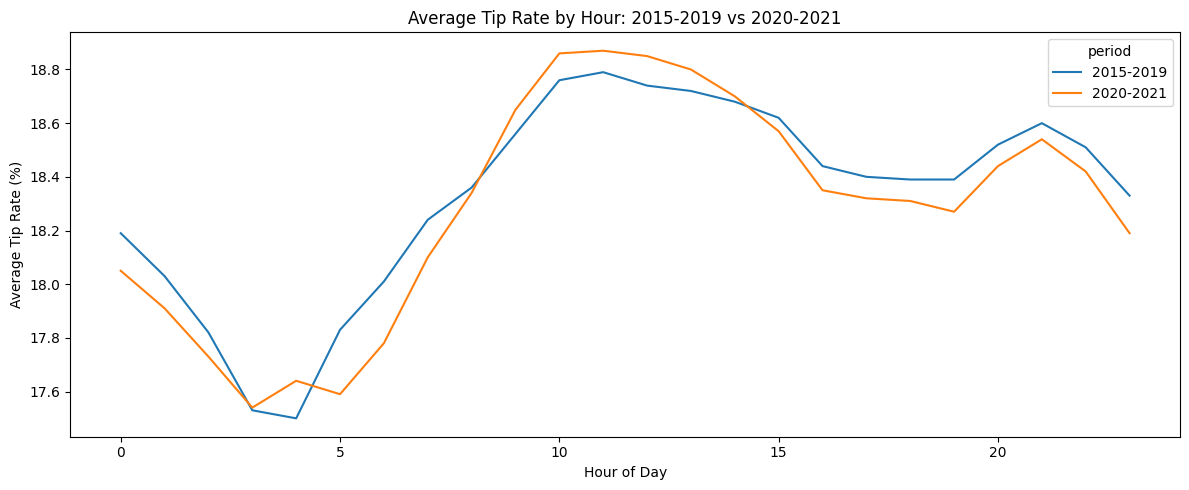

In [28]:
# Tabelle speichern und Liniendiagramm erstellen.

tips_by_hour_period_pd = tips_by_hour_period.toPandas()

tips_by_hour_period_pd.to_csv(
    f"{RESULT_PATH}/tips_by_hour_period.csv",
    index=False
)

period_tip_pivot = tips_by_hour_period_pd.pivot(
    index="pickup_hour",
    columns="period",
    values="avg_tip_rate_percent"
)

ax = period_tip_pivot.plot(
    kind="line",
    figsize=(12, 5),
    title="Average Tip Rate by Hour: 2015-2019 vs 2020-2021"
)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Average Tip Rate (%)")

plt.tight_layout()
plt.savefig(f"{RESULT_PATH}/avg_tip_rate_by_hour_period.png", dpi=150)
plt.show()

In [29]:
spark.stop()